## Plant Disease detection

### Installing dependencies

In [1]:
!pip install kagglehub tensorflow scikit-learn matplotlib seaborn

### Download Dataset

In [21]:
import kagglehub
import os

path = kagglehub.dataset_download("mohitsingh1804/plantvillage")
path = os.path.join(path, "PlantVillage")
print("Dataset path:", path)
print(os.listdir(path)[:10])

Using Colab cache for faster access to the 'plantvillage' dataset.
Dataset path: /kaggle/input/plantvillage/PlantVillage
['val', 'train']


### Imports

In [27]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd
import seaborn as sns

### Parameters

In [33]:
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 10

### Data preprocessing + augmentation

In [34]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
train_path = os.path.join(path, "train")
val_path = os.path.join(path, "val")
train_data = datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = datagen.flow_from_directory(
    val_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_data.class_indices)
print("Number of classes:", num_classes)
print(train_data.class_indices)

Found 43444 images belonging to 38 classes.
Found 10861 images belonging to 38 classes.
Number of classes: 38
{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry__

### CNN model

In [35]:
from tensorflow.keras.layers import Input,BatchNormalization, GlobalAveragePooling2D

model = Sequential([
    Input(shape=(128,128,3)),

    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

### Train model

In [37]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1595s 1s/step - accuracy: 0.5671 - loss: 1.5920 - val_accuracy: 0.7705 - val_loss: 0.8299
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1558s 1s/step - accuracy: 0.7528 - loss: 0.8360 - val_accuracy: 0.8675 - val_loss: 0.4768
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1588s 1s/step - accuracy: 0.8248 - loss: 0.5802 - val_accuracy: 0.8933 - val_loss: 0.3620
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1631s 1s/step - accuracy: 0.8669 - loss: 0.4377 - val_accuracy: 0.9303 - val_loss: 0.2519
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1617s 1s/step - accuracy: 0.8914 - loss: 0.3529 - val_accuracy: 0.9427 - val_loss: 0.1975
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1566s 1s/step - accuracy: 0.9114 - loss: 0.2906 - val_accuracy: 0.9346 - val_loss: 0.2026
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1597s 1s/step - accuracy: 0.9211 - loss: 0.2543 - val_accuracy: 0.9591 - val_loss: 0.1286
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1668s 1s/step - accuracy: 0.9331 -

### Plot accuracy and loss

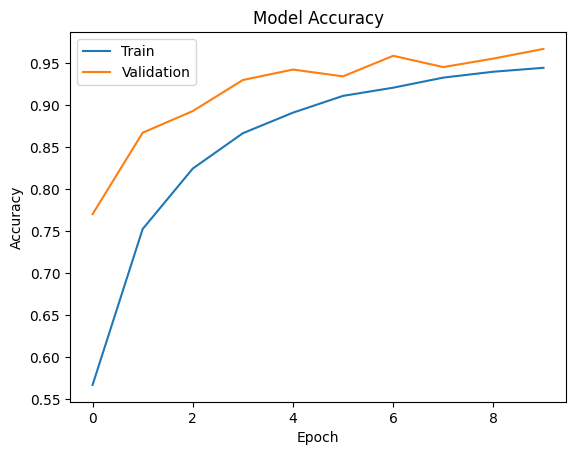

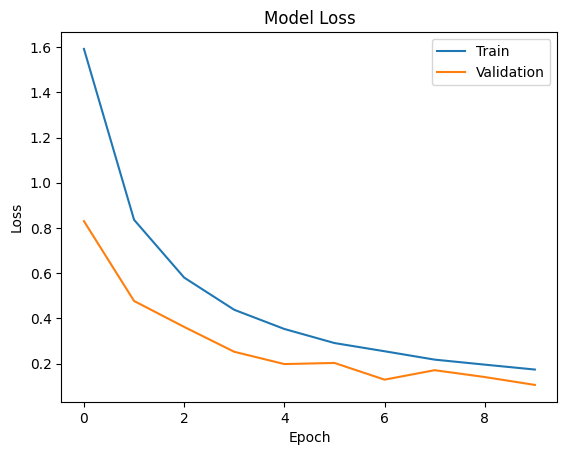

In [38]:

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.savefig("accuracy_plot.png")
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.savefig("loss_plot.png")
plt.show()

### Predictions

In [39]:
val_data.reset()
predictions = model.predict(val_data)

y_pred = np.argmax(predictions, axis=1)
y_true = val_data.classes

340/340 ━━━━━━━━━━━━━━━━━━━━ 105s 309ms/step


### Classification report

In [40]:
class_names = list(val_data.class_indices.keys())

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

print("\nDetailed Classification Report:\n")

for label, metrics in report_dict.items():
    if isinstance(metrics, dict):
        print(f"{label}:")
        print(f"  Precision: {metrics['precision']:.4f}")
        print(f"  Recall:    {metrics['recall']:.4f}")
        print(f"  F1-score:  {metrics['f1-score']:.4f}")
        print()

df_report = pd.DataFrame(report_dict).transpose()
df_report.to_csv("classification_report.csv")


Detailed Classification Report:

Apple___Apple_scab:
  Precision: 0.9231
  Recall:    0.9524
  F1-score:  0.9375

Apple___Black_rot:
  Precision: 0.9841
  Recall:    0.9920
  F1-score:  0.9880

Apple___Cedar_apple_rust:
  Precision: 1.0000
  Recall:    0.9636
  F1-score:  0.9815

Apple___healthy:
  Precision: 0.9630
  Recall:    0.9483
  F1-score:  0.9556

Blueberry___healthy:
  Precision: 0.9610
  Recall:    0.9867
  F1-score:  0.9737

Cherry_(including_sour)___Powdery_mildew:
  Precision: 0.9718
  Recall:    0.9857
  F1-score:  0.9787

Cherry_(including_sour)___healthy:
  Precision: 0.9641
  Recall:    0.9471
  F1-score:  0.9555

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot:
  Precision: 0.8214
  Recall:    0.8932
  F1-score:  0.8558

Corn_(maize)___Common_rust_:
  Precision: 0.9834
  Recall:    0.9916
  F1-score:  0.9875

Corn_(maize)___Northern_Leaf_Blight:
  Precision: 0.9457
  Recall:    0.8832
  F1-score:  0.9134

Corn_(maize)___healthy:
  Precision: 0.9628
  Recall:    1

### overall metrices

In [41]:
print("\nOverall Metrics:\n")

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


Overall Metrics:

Accuracy : 0.9658
Precision: 0.9671
Recall   : 0.9658
F1 Score : 0.9660


### Confusion matrix

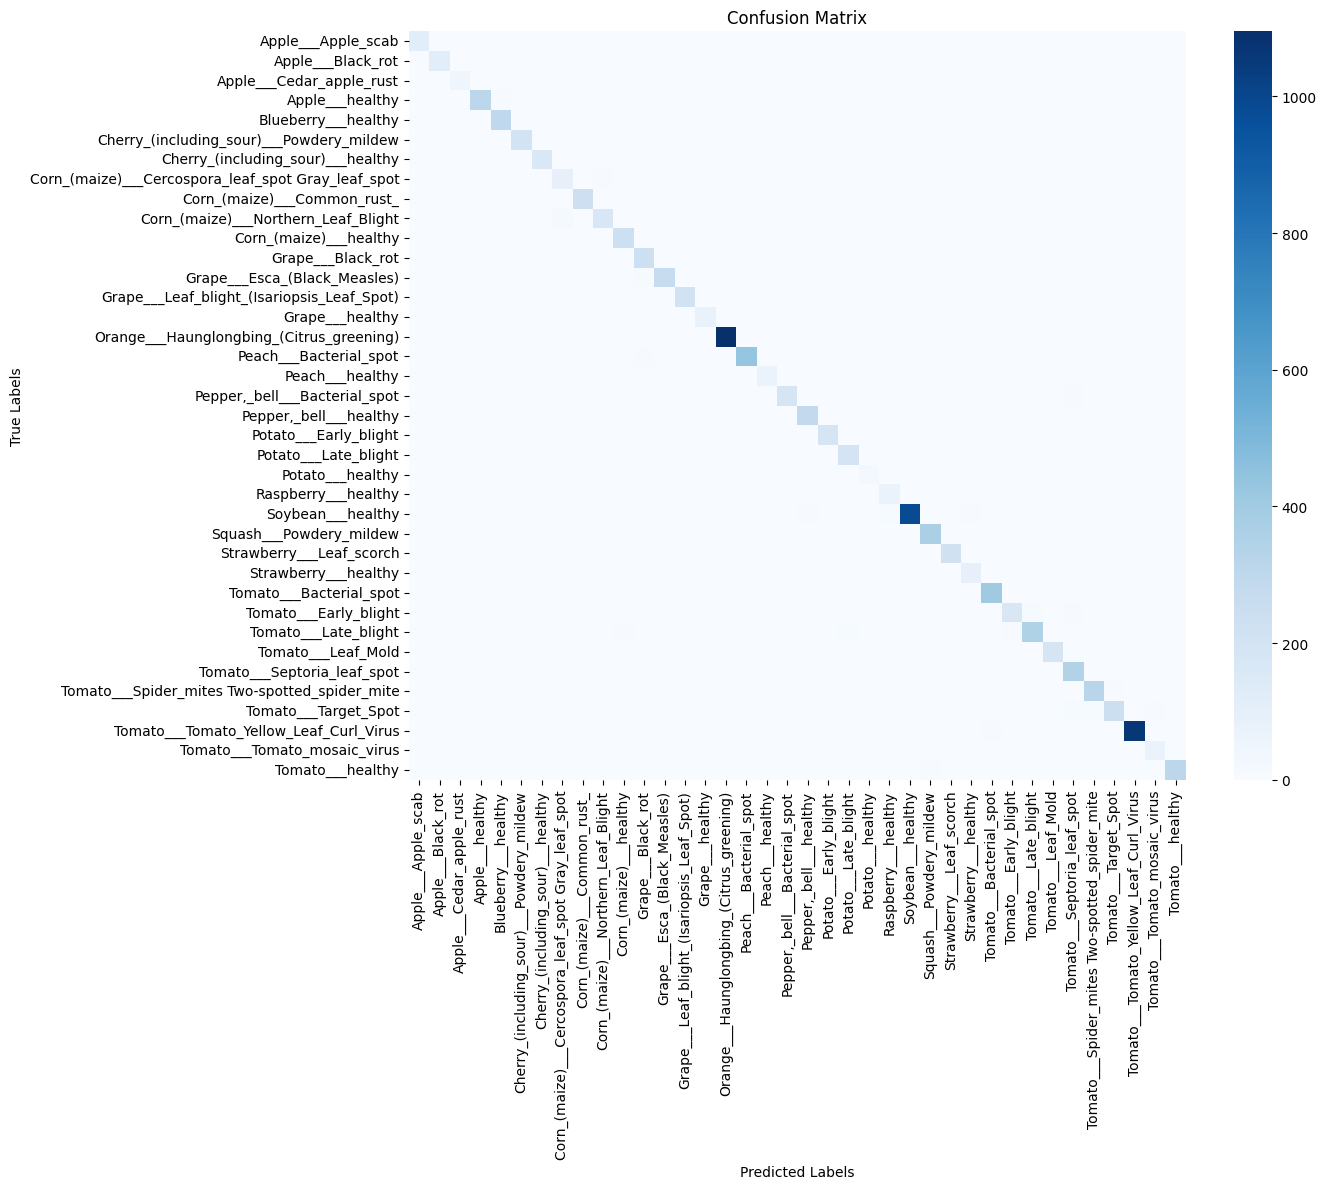

In [42]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14,12))
sns.heatmap(
    cm,
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

### save model & results

In [43]:
model.save("plant_disease_cnn_model.h5")
with open("final_metrics.txt", "w") as f:
    f.write(f"Accuracy: {accuracy:.4f}\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall: {recall:.4f}\n")
    f.write(f"F1 Score: {f1:.4f}\n")

print("\n✅ Model and all report files saved successfully!")


✅ Model and all report files saved successfully!
